Проверить точность бинарной классификации кошек/собак и точность классификации изображений по породам с помощью фундаментальной предобученной сети CLIP и текстовых промптов, построить матрицу ошибок.

In [14]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-oqo5bd9j
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-oqo5bd9j
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [15]:
import torch
import clip
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets
from sklearn.metrics import confusion_matrix, accuracy_score
from tqdm import tqdm

CLIP анализирует изображения...


100%|██████████| 100/100 [00:05<00:00, 16.93it/s]



Точность CLIP (Бинарная Кот/Собака): 100.00%
Точность CLIP (Породы): 87.00%


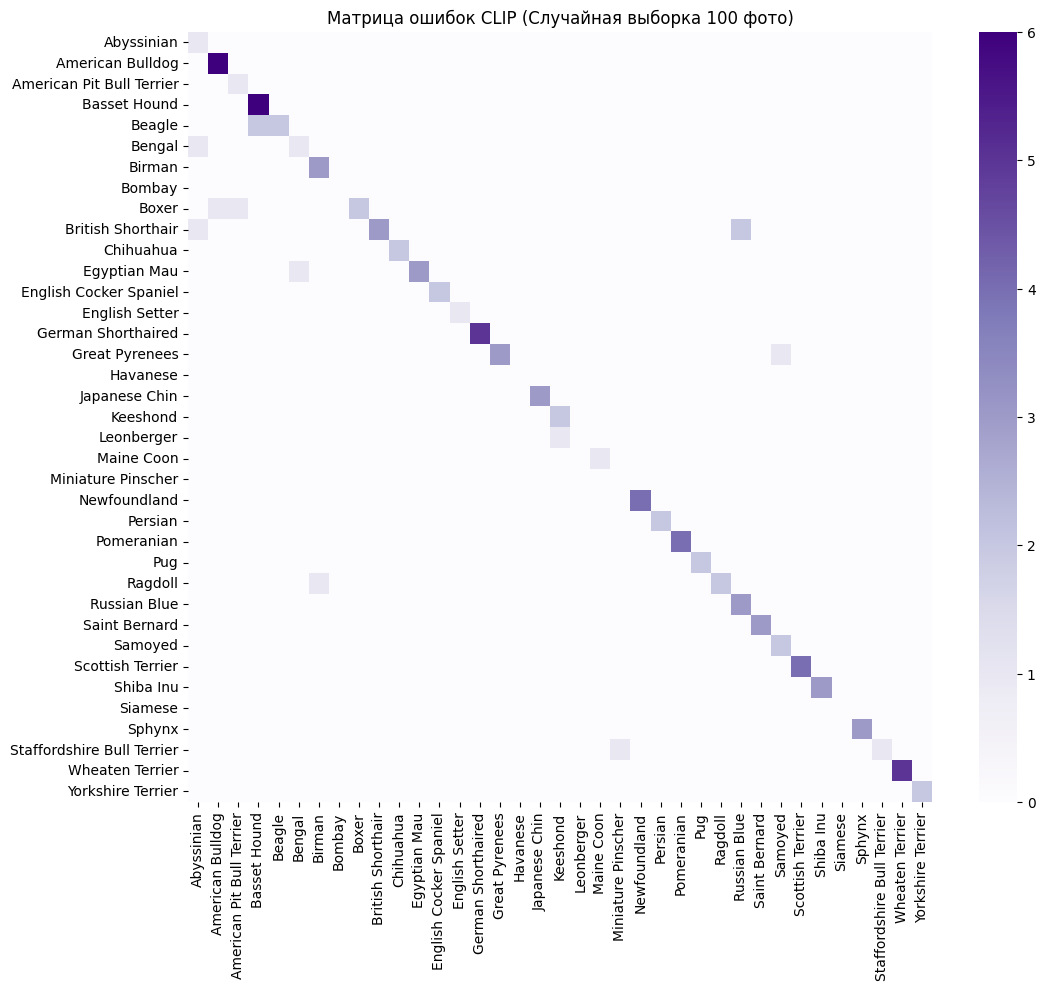

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

dataset = datasets.OxfordIIITPet(root='.', split='test', download=True)
classes = [c.replace('_', ' ') for c in dataset.classes]

cat_breeds = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 
    'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 
    'Russian Blue', 'Siamese', 'Sphynx'
]
cat_breeds_lower = [c.lower().replace('_', ' ') for c in cat_breeds]

binary_descriptions = ["a photo of a dog", "a photo of a cat"]
binary_tokens = clip.tokenize(binary_descriptions).to(device)

breed_descriptions = [f"a photo of a {c}, a pet" for c in classes]
breed_tokens = clip.tokenize(breed_descriptions).to(device)

y_true_breed, y_pred_breed = [], []
y_true_bin, y_pred_bin = [], []

random.seed(42)
sample_indices = random.sample(range(len(dataset)), 100)

print("CLIP анализирует изображения...")
for i in tqdm(sample_indices): 
    img, label = dataset[i]
    img_input = preprocess(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits_breed, _ = model(img_input, breed_tokens)
        y_pred_breed.append(logits_breed.argmax().item())
        y_true_breed.append(label)
        
        logits_bin, _ = model(img_input, binary_tokens)
        y_pred_bin.append(logits_bin.argmax().item())
        
        breed_name = dataset.classes[label].lower().replace('_', ' ')
        is_cat = 1 if breed_name in cat_breeds_lower else 0
        y_true_bin.append(is_cat)

print("\n" + "="*30)
print(f"Точность CLIP (Бинарная Кот/Собака): {accuracy_score(y_true_bin, y_pred_bin)*100:.2f}%")
print(f"Точность CLIP (Породы): {accuracy_score(y_true_breed, y_pred_breed)*100:.2f}%")
print("="*30)

plt.figure(figsize=(12,10))
cm = confusion_matrix(y_true_breed, y_pred_breed, labels=range(len(classes)))
sns.heatmap(cm, annot=False, cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок CLIP (Случайная выборка 100 фото)')
plt.xticks(rotation=90)
plt.show()